## Self-TICA: Learning slow modes via self-supervised learning.

## Introduction

### Dataset construction for self-supervised learning

SelfTICA learns molecular representations directly from molecular dynamics trajectories. Given a trajectory of configurations $\{\mathbf{R}_t\}$ and a lag time $\tau$, we construct time-lagged pairs,

$$
(\mathbf{R}_t,\mathbf{R}_{t+\tau}).
$$

Within each mini-batch, $\mathbf{R}_t^{(i)}$ and its lagged counterpart $\mathbf{R}_{t+\tau}^{(i)}$ are treated as a positive pair, while mismatched configurations $\mathbf{R}_t^{(i)}$ and $\mathbf{R}_{t+\tau}^{(j)}$ with $i\neq j$ are treated as negative pairs. This construction allows the model to learn dynamical representations from trajectories without predefined state labels.

The training trajectories can be generated from either unbiased MD simulations or biased/exploratory simulations. Unbiased trajectories directly reflect equilibrium dynamics, whereas biased or exploratory trajectories can provide broader configurational sampling when spontaneous transitions are rare.

### Contrastive loss

An encoder $\varphi$ maps each configuration to a latent representation,

$$
\mathbf{z}_t
=
\varphi(\mathbf{R}_t),
$$

and a predictor $P$ maps the current representation toward the lagged one,

$$
P\mathbf{z}_t
\approx
\mathbf{z}_{t+\tau}.
$$

The similarity between sample $i$ at time $t$ and sample $j$ at time $t+\tau$ is defined as

$$
D_{ij}
=
\left\langle
P\mathbf{z}_t^{(i)},
\mathbf{z}_{t+\tau}^{(j)}
\right\rangle .
$$

The SelfTICA contrastive loss is

$$
\mathcal{L}(\varphi, P)
=
\frac{1}{N(N-1)}
\sum_{i\neq j} D_{ij}^{2}
-
\frac{2}{N}
\sum_{i=1}^{N} D_{ii}.
$$

The first term suppresses similarity between negative pairs, while the second term promotes similarity between positive pairs. As a result, the encoder is encouraged to retain information that is predictive over the lag time $\tau$.

### Connection to the VAMP-2 loss

Given an encoder $\varphi$, SelfTICA maps each configuration to a latent representation,

$$
\mathbf{z}_t = \varphi(\mathbf{R}_t).
$$

For a fixed encoder, the optimal predictor is

$$
P^*
=
C_{00}^{-1} C_{0\tau} C_{\tau\tau}^{-1},
$$

where

$$
C_{00}=\langle \mathbf{z}_t\mathbf{z}_t^\top\rangle,
\qquad
C_{\tau\tau}=\langle \mathbf{z}_{t+\tau}\mathbf{z}_{t+\tau}^\top\rangle,
\qquad
C_{0\tau}=\langle \mathbf{z}_t\mathbf{z}_{t+\tau}^\top\rangle .
$$

Substituting $P^*$ into the contrastive objective gives

$$
\mathcal{L}(\varphi,P^*)
=
-
\left\|
C_{00}^{-1/2}
C_{0\tau}
C_{\tau\tau}^{-1/2}
\right\|_F^2 ,
$$

up to constants independent of the encoder. Thus, minimizing the contrastive loss is equivalent to maximizing a VAMP-2-type score, encouraging the encoder to learn the dominant slow dynamical subspace.

For reversible equilibrium dynamics, this reduces to the VAC/TICA form,

$$
\mathcal{L}(\varphi,P^*)
=
-\sum_i \lambda_i^2 .
$$

### Linear and nonlinear predictors

The choice of predictor depends on the type of trajectory used for training.

For unbiased equilibrium trajectories, the time-lagged evolution in the learned feature space can be naturally approximated by a linear predictor, consistent with the Koopman-operator view.

For biased or exploratory trajectories, the applied bias modifies the effective dynamics. At the generator level,

$$
\mathcal{L}' f
=
\mathcal{L} f
+
\nabla V \cdot \nabla f .
$$

The corresponding finite-time propagator is

$$
\mathcal{T}'_{\tau}
=
e^{\tau\mathcal{L}'}
=
e^{\tau(\mathcal{L}+\Delta\mathcal{L})}.
$$

Because $\mathcal{L}$ and $\Delta\mathcal{L}$ generally do not commute, the effect of bias cannot be written as a simple linear correction to the unbiased propagator. After projection onto a finite-dimensional learned feature space, a single global linear predictor may therefore be insufficient. SelfTICA thus uses a nonlinear predictor for biased or exploratory trajectories to better approximate the effective finite-time dynamics.

### TICA in the learned feature space for CV construction

After training, the encoder provides a latent representation,

$$
\mathbf{z}
=
\varphi(\mathbf{R}),
$$

which retains time-lagged dynamical information. However, the individual latent coordinates are not necessarily orthogonal slow modes. Therefore, TICA is applied a posteriori in the learned feature space.

The TICA components are defined as

$$
\tilde{\psi}_i(\mathbf{R})
=
\mathbf{w}_i^\top \varphi(\mathbf{R}),
$$

where $\mathbf{w}_i$ is obtained from the generalized eigenvalue problem

$$
C_{\tau}\mathbf{w}_i
=
\tilde{\lambda}_i C_0\mathbf{w}_i .
$$

This identifies linear combinations of encoder features with maximal time-lagged autocorrelation. The leading TICA component is then used as the collective variable for enhanced sampling,

$$
s(\mathbf{R})
=
\tilde{\psi}_1(\mathbf{R}).
$$

### Advantages of SelfTICA

SelfTICA offers three main advantages. First, it decouples representation learning from slow-mode extraction: the encoder learns a reusable dynamical feature space, while TICA extracts orthogonal slow modes afterward, avoiding unstable direct eigendecomposition optimization. Second, the learned representation is not tied to a single lag time, allowing spectra, implied timescales, and CVs to be evaluated at different lag times without retraining. Third, SelfTICA can learn useful CVs from limited, biased, or exploratory trajectories, reducing the need for long unbiased simulations or fully converged biased dynamics.

<center><img src="images/selftica.png" width="800" /></center>

## Setup

In [1]:
# Colab setup
import os

if os.getenv("COLAB_RELEASE_TAG"):
    import subprocess
    subprocess.run('wget https://raw.githubusercontent.com/luigibonati/mlcolvar/main/colab_setup.sh', shell=True)
    cmd = subprocess.run('bash colab_setup.sh TUTORIAL', shell=True, stdout=subprocess.PIPE)
    print(cmd.stdout.decode('utf-8'))

# IMPORT PACKAGES
import torch
import lightning
import numpy as np
import matplotlib.pyplot as plt

# IMPORT HELPER FUNCTIONS
from mlcolvar.utils.plot import muller_brown_potential, plot_isolines_2D

# Set seed for reproducibility
torch.manual_seed(42)
torch.set_default_dtype(torch.float64)

## Load data

In [2]:
from mlcolvar.io import load_dataframe
from mlcolvar.utils.timelagged import create_timelagged_dataset
from mlcolvar.data import DictModule

filenames = [ "data/muller-brown/biased/opes-y/COLVAR"]

# load file
df = load_dataframe(filenames, start=0, stop=10000, stride=5)

# get descriptors
X = df.filter(regex='p.x|p.y').values

# build time-lagged dataset (composed by pairs of configs at time t, t+lag)
dataset = create_timelagged_dataset(X, lag_time=1)

# create datamodule 
datamodule = DictModule(dataset, lengths=[0.8, 0.2])

### Define model
Here are a few tips and tricks about the hyperparameters:
- The self-supervised loss $\varepsilon(\phi, P^*)$ converges to the negative VAMP-2 score only when the predictor $P$ reaches its optimal form $P^*$. Therefore, do not be confused if the eigenvalues decrease during the initial stages of training, this is a normal behavior.
- The algorithm requires sufficient model expressiveness so that the predictor $P$ can approximate its optimal form.  If the predictor is too weak, the eigenvalues may collapse toward zero. It is recommended to use an encoder with at least three layers to ensure stable learning.
- Beware of overfitting. It is recommended to stop training once the eigenvalues have stabilized or converged, as continuing beyond this point may cause the learned CVs to become overly sharp or narrowly shaped.

In [3]:
from mlcolvar.cvs import SelfTICA

n_components = 1
encoder_layers = [2, 15, 15, 5]
options= {'nn': {'activation': 'shifted_softplus'}}

model = SelfTICA(encoder_layers, predictor_depth=3, n_cvs=n_components, options=options)

model

SelfTICA(
  (loss_fn): ContrastiveLoss()
  (norm_in): Normalization(in_features=2, out_features=2, mode=mean_std)
  (nn): FeedForward(
    (nn): Sequential(
      (0): Linear(in_features=2, out_features=15, bias=True)
      (1): Shifted_Softplus(beta=1, threshold=20)
      (2): Linear(in_features=15, out_features=15, bias=True)
      (3): Shifted_Softplus(beta=1, threshold=20)
      (4): Linear(in_features=15, out_features=5, bias=True)
    )
  )
  (predictor): FeedForward(
    (nn): Sequential(
      (0): Linear(in_features=5, out_features=5, bias=True)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=5, out_features=5, bias=True)
    )
  )
  (tica): TICA(in_features=5, out_features=1)
)

### Define Trainer & Fit

In [4]:
from mlcolvar.utils.trainer import MetricsCallback

# define callbacks
metrics = MetricsCallback()

# define trainer
trainer = lightning.Trainer(callbacks=[metrics],
                     max_epochs=200, logger=None, enable_checkpointing=False)

# fit
trainer.fit( model, datamodule )

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
e:\anaconda3\envs\mlcolvar-gnn\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name      | Type            | Params | Mode  | FLOPs | In sizes | Out sizes
---------------------------------------------------------------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

e:\anaconda3\envs\mlcolvar-gnn\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
e:\anaconda3\envs\mlcolvar-gnn\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


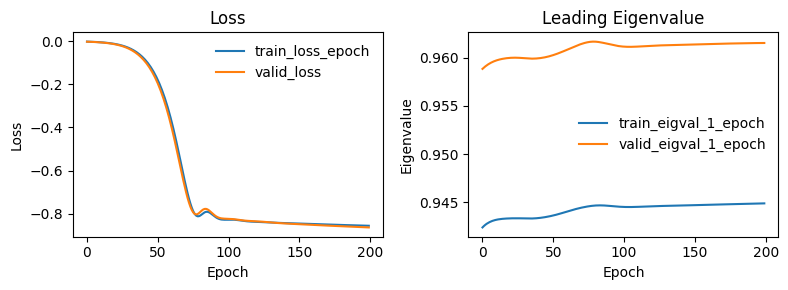

In [5]:
from mlcolvar.utils.plot import plot_metrics

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), sharex=True)

plot_metrics(
    metrics.metrics,
    keys=['train_loss_epoch', 'valid_loss'],
    ax=ax1,
    yscale='linear'
)
ax1.set_ylabel('Loss')
ax1.set_title('Loss')

plot_metrics(
    metrics.metrics,
    keys=['train_eigval_1_epoch', 'valid_eigval_1_epoch'],
    ax=ax2,
    yscale='linear'
)
ax2.set_ylabel('Eigenvalue')
ax2.set_title('Leading Eigenvalue')

plt.xlabel('Epoch')
plt.tight_layout()
plt.show()

### Plot encoder features

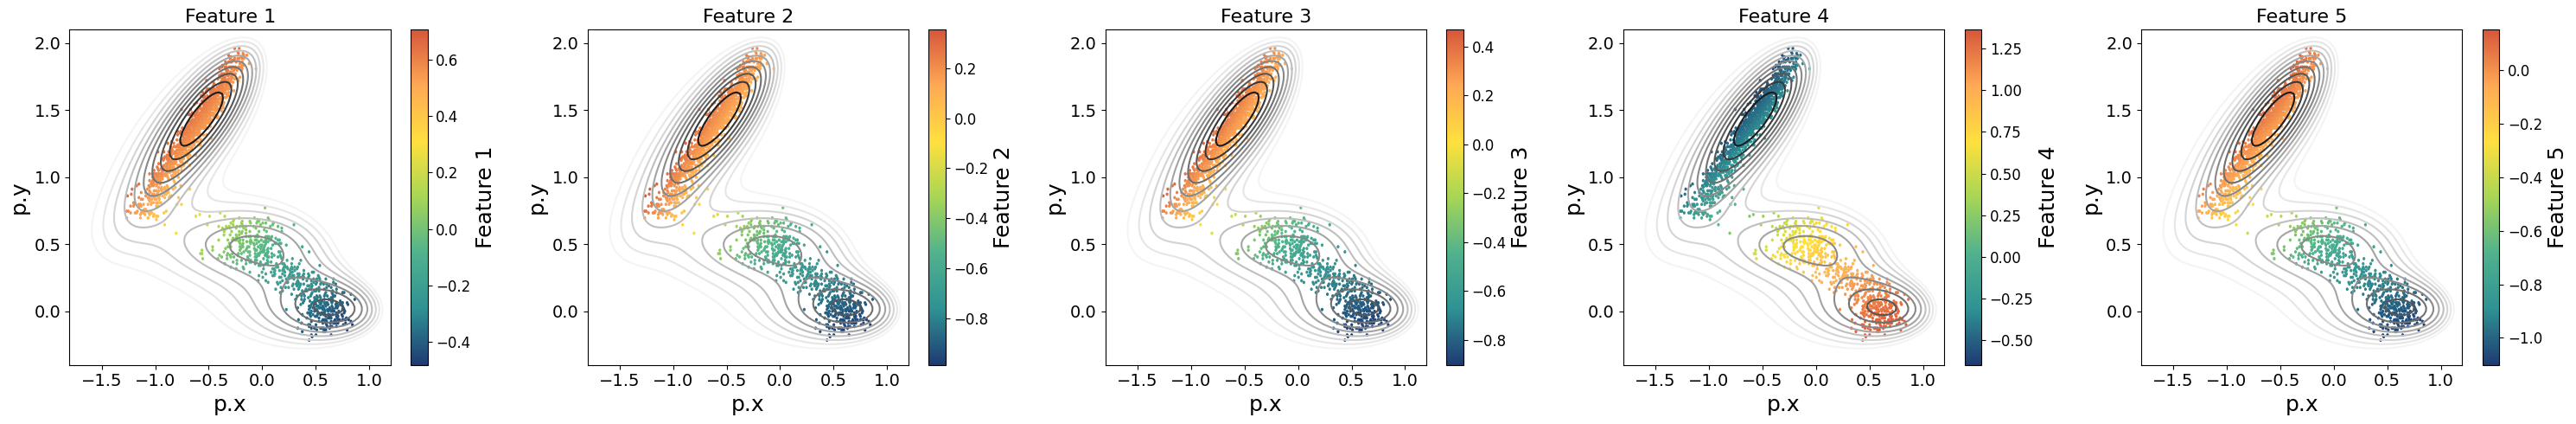

In [6]:
fig, axs = plt.subplots(1, 5, figsize=(6*5, 5), dpi=100)  
axs = axs.flatten()

x = df['p.x'].values
y = df['p.y'].values

# Evaluate encoder features 
with torch.no_grad():
    model.train()
    s = model(torch.Tensor(X)).numpy()
    n = min(len(X), len(x), len(y))

# Plot the first five learned features
for i in range(5):  
    ax = axs[i]
    pp = ax.hexbin(x[:n], y[:n], C=s[:n, i], gridsize=150, cmap='fessa')

    plot_isolines_2D(
        muller_brown_potential,
        levels=np.linspace(0, 24, 12),
        mode='contour',
        ax=ax
    )

    # colorbar
    cbar = plt.colorbar(pp, ax=ax)
    cbar.set_label(f'Feature {i+1}', fontsize=18)
    cbar.ax.tick_params(labelsize=12)

    # Set title and axis labels
    ax.set_title(f'Feature {i+1}', fontsize=16)
    ax.set_xlabel('p.x', fontsize=18)
    ax.set_ylabel('p.y', fontsize=18)

    # Customize tick parameters
    ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

### Normalize output 
For a consistent CV scale in analysis and enhanced-sampling simulations

In [7]:
from mlcolvar.core.transform import Normalization
from mlcolvar.core.transform.utils import Statistics

with torch.no_grad():
    model.eval()
    model.postprocessing = None # reset
    s = model(torch.Tensor(X))

norm =  Normalization(n_components, mode='min_max', stats = Statistics(s) )
model.postprocessing = norm
#print(Statistics(s))

### Plot FES

Text(0, 0.5, 'FES (kJ/mol)')

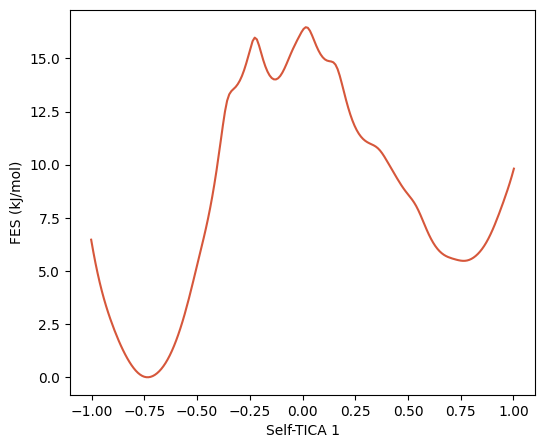

In [8]:
from mlcolvar.utils.fes import compute_fes

beta=1.
bias = df.filter(regex='opes.bias').values.sum(axis=1)
logweights = beta*bias
w = np.exp(logweights)

fig,ax = plt.subplots(1,1,figsize=(6,5),dpi=100)

# compute cvs
with torch.no_grad():
    model.eval()
    s = model(torch.Tensor(X)).numpy()

fes,grid,bounds,error = compute_fes(s,
                                    kbt=1,
                                    weights=w,
                                    blocks=1,
                                    bandwidth=0.02, scale_by='range',
                                    plot=True, plot_max_fes=20, ax = ax)

ax.set_xlabel('Self-TICA 1')
ax.set_ylabel('FES (kJ/mol)')

### Plot CVs isolines

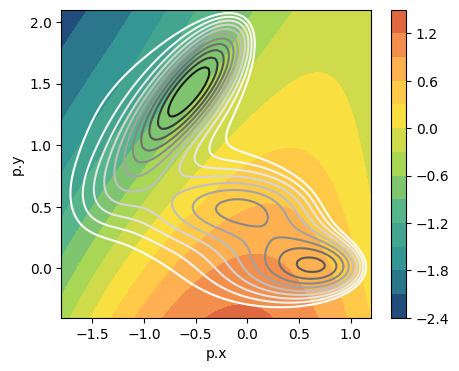

In [9]:
fig,axs = plt.subplots( 1, n_components, figsize=(5*n_components,4) )
if n_components == 1:
    axs = [axs]
for i in range(n_components):
    ax = axs[i]

    plot_isolines_2D(muller_brown_potential, levels=np.linspace(0,24,12),mode='contour',ax=ax)
    cs= plot_isolines_2D(model, component=i, ax=ax)
    cbar.set_label(f'TICA 1')
    ax.set_xlabel('p.x')
    ax.set_ylabel('p.y')

### Predict other lag-time

In [10]:
dataset = create_timelagged_dataset(X, lag_time=100,progress_bar=True)
datamodule = DictModule(dataset,lengths=[1], batch_size=5000, random_split=False, shuffle=False)
datamodule.setup()
model.compute_tica(datamodule, lag_time=100, update_optimal=True)

E:\Github\SelfTICA\mlcolvar\mlcolvar\data\datamodule.py:136: UserWarning: A torch.generator was provided but it is not used with random_split=False
  warnings.warn(


(array([0.04927651]),
 array([[ 0.23174113],
        [-0.13195652],
        [ 0.22762288],
        [ 0.62016707],
        [ 0.7017579 ]]))

Text(0, 0.5, 'FES (kJ/mol)')

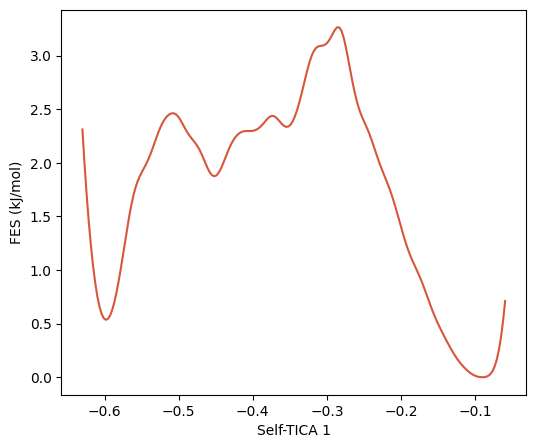

In [11]:
fig,ax = plt.subplots(1,1,figsize=(6,5),dpi=100)

# compute cvs
with torch.no_grad():
    model.eval()
    s = model(torch.Tensor(X)).numpy()

fes,grid,bounds,error = compute_fes(s,
                                    kbt=1,
                                    blocks=1,
                                    bandwidth=0.02, scale_by='range',
                                    plot=True, plot_max_fes=20, ax = ax)

ax.set_xlabel('Self-TICA 1')
ax.set_ylabel('FES (kJ/mol)')

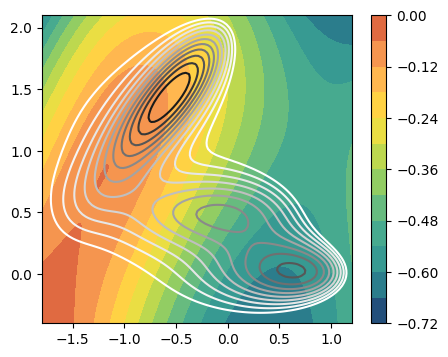

In [12]:
fig,axs = plt.subplots( 1, n_components, figsize=(5*n_components,4) )
if n_components == 1:
    axs = [axs]
for i in range(n_components):
    ax = axs[i]

    plot_isolines_2D(muller_brown_potential,levels=np.linspace(0,24,12),mode='contour',ax=ax)
    plot_isolines_2D(model, component=i, ax=ax)
    #ax.scatter(X[:,0],X[:,1],s=1, alpha=0.2,c='w')